In [1]:
import numpy as np;
import pandas as pd;
import seaborn as sns;
import matplotlib.pyplot as plt;
from pandas import DataFrame,Series

In [2]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import plotly.figure_factory as ff

In [3]:
df = pd.read_csv("/content/Amazon Sale Report.csv",encoding="latin1")
df

/tmp/ipykernel_2597/1772517076.py:1: DtypeWarning: Columns (23) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/Amazon Sale Report.csv",encoding="latin1")


,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
128970,128970,406-6001380-7673107,05-31-22,Shipped,Amazon,Amazon.in,Expedited,JNE3697,JNE3697-KR-XL,kurta,...,INR,517.00,HYDERABAD,TELANGANA,500013.0,IN,NaN,False,NaN,False
128971,128971,402-9551604-7544318,05-31-22,Shipped,Amazon,Amazon.in,Expedited,SET401,SET401-KR-NP-M,Set,...,INR,999.00,GURUGRAM,HARYANA,122004.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
128972,128972,407-9547469-3152358,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0157,J0157-DR-XXL,Western Dress,...,INR,690.00,HYDERABAD,TELANGANA,500049.0,IN,NaN,False,NaN,False
128973,128973,402-6184140-0545956,05-31-22,Shipped,Amazon,Amazon.in,Expedited,J0012,J0012-SKD-XS,Set,...,INR,1199.00,Halol,Gujarat,389350.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [4]:
df.shape

(128975, 24)

In [5]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='object')

In [6]:
df.drop(columns=['Unnamed: 22'],inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 23 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

In [8]:
df.isnull().sum()

,0
index,0
Order ID,0
Date,0
Status,0
Fulfilment,0
Sales Channel,0
ship-service-level,0
Style,0
SKU,0
Category,0


we have null values in courier status,currency,amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,fulfilled-by

## **Outliers are not defined for categorical columns like Courier_Status, Currency, ship_city, etc.**

In [9]:
df.describe()

,index,Qty,Amount,ship-postal-code
count,128975.000000,128975.000000,121180.000000,128942.000000
mean,64487.000000,0.904431,648.561465,463966.236509
std,37232.019822,0.313354,281.211687,191476.764941
min,0.000000,0.000000,0.000000,110001.000000
25%,32243.500000,1.000000,449.000000,382421.000000
50%,64487.000000,1.000000,605.000000,500033.000000
75%,96730.500000,1.000000,788.000000,600024.000000
max,128974.000000,15.000000,5584.000000,989898.000000


In [10]:
df = df.rename(columns={'Order ID': 'Order_ID', 'Sales Channel ': 'Sales_channel',
        'ship-service-level': 'ship_service_level', 'ship-city': 'ship_city',
        'ship-state': 'ship_state', 'ship-postal-code': 'ship_postal_code', 'ship-country': 'ship_country',
        'promotion-ids': 'promotion_ids','Courier Status': 'Courier_Status', 'currency': 'Currency',
        'fulfilled-by':'fulfilled_by'})

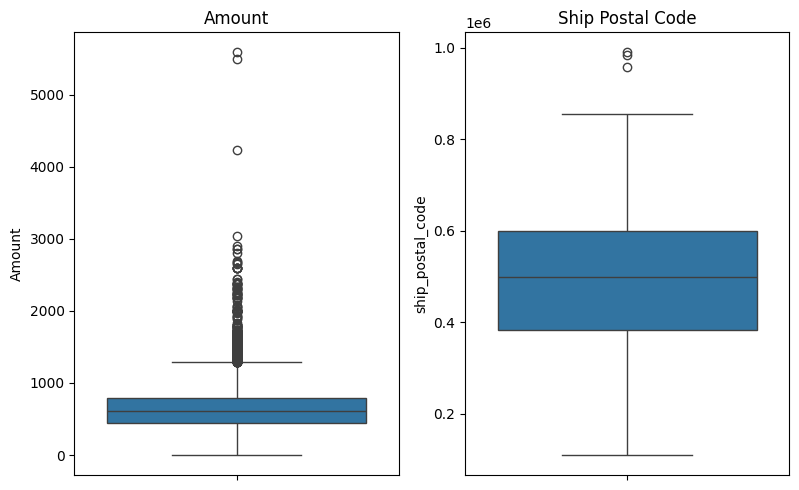

In [11]:
plt.figure(figsize=(12,5))


plt.subplot(1,3,1)
sns.boxplot(y=df["Amount"])
plt.title("Amount")

plt.subplot(1,3,2)
sns.boxplot(y=df["ship_postal_code"])
plt.title("Ship Postal Code")

plt.tight_layout()
plt.show()

In [12]:
Q1=df["Amount"].quantile(0.25)
Q3=df["Amount"].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df["Amount"]<lower) | (df["Amount"]>upper)]

print("Lower limit:",lower)
print("Upper limit:",upper)
print("Number of outliers:",len(outliers))

Lower limit: -59.5
Upper limit: 1296.5
Number of outliers: 3600


In [13]:
df["Amount"]=df["Amount"].clip(lower,upper)

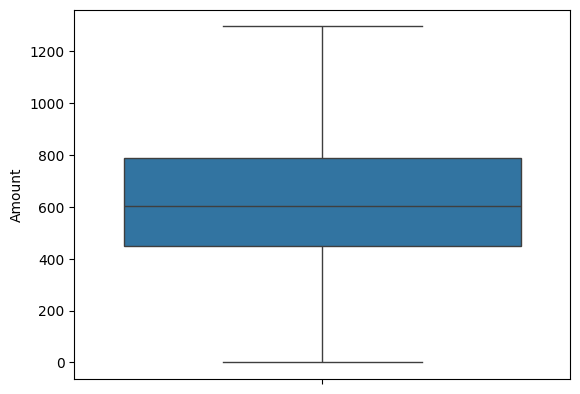

In [14]:
sns.boxplot(y=df["Amount"])
plt.show()

In [15]:
Q1=df["ship_postal_code"].quantile(0.25)
Q3=df["ship_postal_code"].quantile(0.75)
IQR=Q3-Q1

lower=Q1-1.5*IQR
upper=Q3+1.5*IQR

outliers=df[(df["ship_postal_code"]<lower) | (df["ship_postal_code"]>upper)]

print("Lower limit:", lower)
print("Upper limit:", upper)
print("Number of outliers:", len(outliers))

Lower limit: 56016.5
Upper limit: 926428.5
Number of outliers: 3


In [16]:
df["ship_postal_code"] = df["ship_postal_code"].clip(lower,upper)

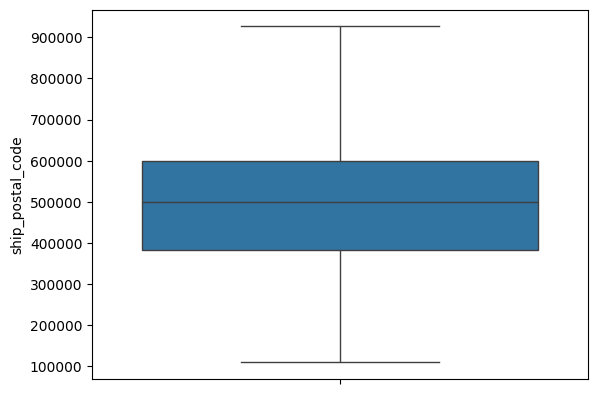

In [17]:
sns.boxplot(y=df["ship_postal_code"])
plt.show()

**Categorical columns**

In [18]:
df["Courier_Status"].value_counts()

,count
Courier_Status,
Shipped,109487
Unshipped,6681
Cancelled,5935


In [19]:
# Fill categorical columns
df["Courier_Status"] = df["Courier_Status"].fillna("Unknown")
df["Currency"] = df["Currency"].fillna(df["Currency"].mode()[0])
df["promotion_ids"] = df["promotion_ids"].fillna("No Promotion")
df["fulfilled_by"] = df["fulfilled_by"].fillna("Unknown")

# Fill numeric column
df["Amount"] = df["Amount"].fillna(df["Amount"].median())

# Remove rows with missing address details
df = df.dropna(subset=[
    "ship_city",
    "ship_state",
    "ship_postal_code",
    "ship_country"
])

In [20]:
print(df.isnull().sum())

index                 0
Order_ID              0
Date                  0
Status                0
Fulfilment            0
Sales_channel         0
ship_service_level    0
Style                 0
SKU                   0
Category              0
Size                  0
ASIN                  0
Courier_Status        0
Qty                   0
Currency              0
Amount                0
ship_city             0
ship_state            0
ship_postal_code      0
ship_country          0
promotion_ids         0
B2B                   0
fulfilled_by          0
dtype: int64


**1. Which categories have sold the most?**

In [21]:
category_sales = df["Category"].value_counts()
print(category_sales)

Category
Set              50272
kurta            49859
Western Dress    15499
Top              10620
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64


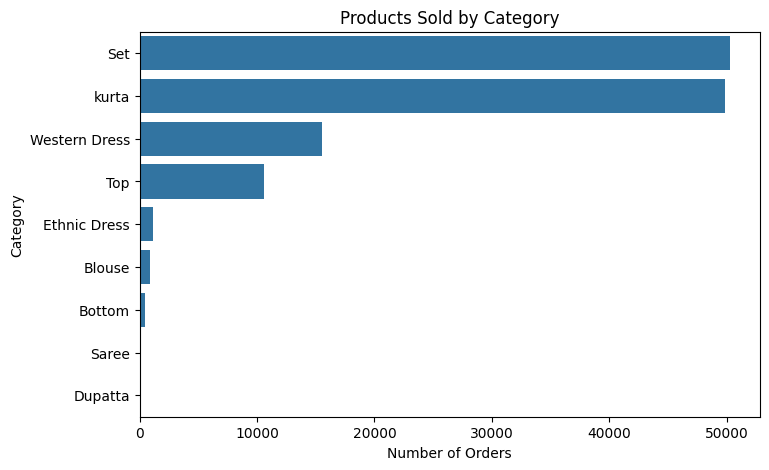

In [22]:
plt.figure(figsize=(8,5))
sns.barplot(x=category_sales.values,y=category_sales.index)
plt.title("Products Sold by Category")
plt.xlabel("Number of Orders")
plt.ylabel("Category")
plt.show()

**2. Which are the 20 Best-Selling Products?**

In [23]:
top_products=df.groupby("SKU")["Qty"].sum().sort_values(ascending=False).head(20)
print(top_products)

SKU
JNE3797-KR-L       661
JNE3797-KR-M       560
JNE3797-KR-S       503
JNE3405-KR-L       485
J0230-SKD-M        468
J0230-SKD-S        421
JNE3797-KR-XL      415
JNE3405-KR-S       399
JNE3797-KR-XS      386
SET268-KR-NP-XL    373
JNE3797-KR-XXL     359
JNE3797-KR-XXXL    353
SET268-KR-NP-S     350
SET268-KR-NP-L     348
JNE3405-KR-M       344
JNE3567-KR-M       291
SET183-KR-DH-M     288
J0003-SET-S        279
J0230-SKD-L        272
J0341-DR-M         268
Name: Qty, dtype: int64


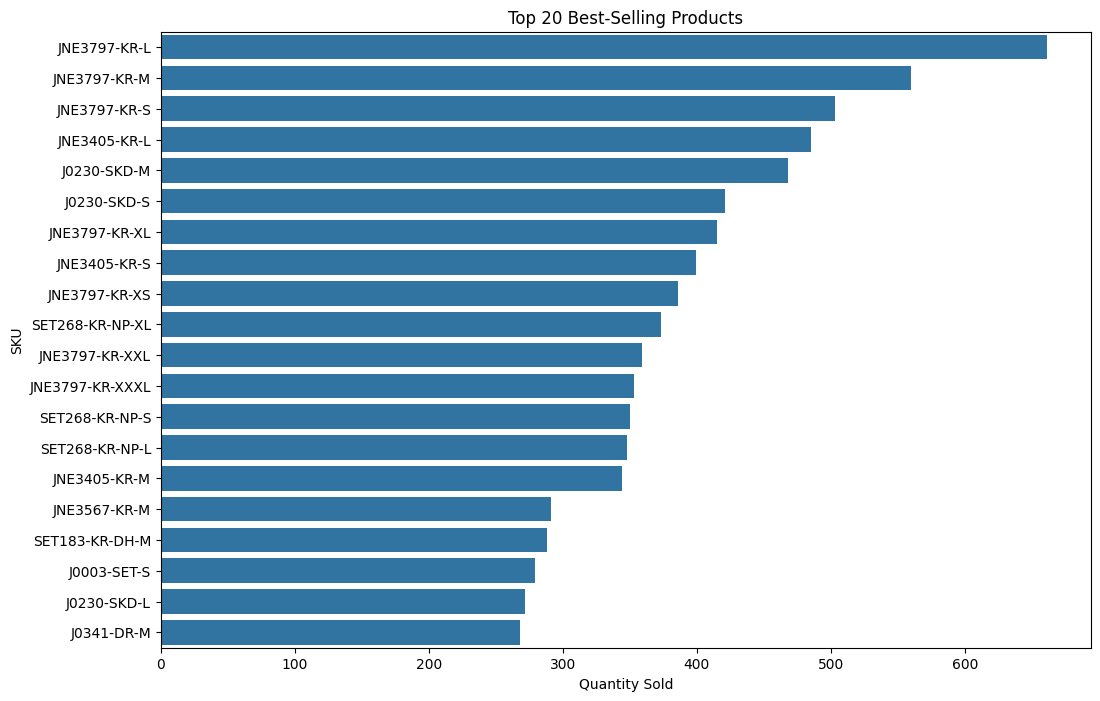

In [24]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_products.values, y=top_products.index)
plt.title("Top 20 Best-Selling Products")
plt.xlabel("Quantity Sold")
plt.ylabel("SKU")
plt.show()

**3. Which are the 20 Best-Selling Products by Revenue?**

In [25]:
top_revenue=df.groupby("SKU")["Amount"].sum().sort_values(ascending=False).head(20)
print(top_revenue)

SKU
JNE3797-KR-L       555263.27
J0230-SKD-M        542544.20
J0230-SKD-S        490300.14
JNE3797-KR-M       473996.16
JNE3797-KR-S       427627.07
JNE3797-KR-XL      348676.24
JNE3797-KR-XS      316327.70
J0230-SKD-L        315017.45
SET268-KR-NP-XL    292249.46
SET268-KR-NP-S     289641.48
JNE3797-KR-XXXL    283482.30
JNE3797-KR-XXL     282621.88
SET268-KR-NP-L     267511.50
J0230-SKD-XL       265208.08
SET183-KR-DH-M     254857.98
J0341-DR-M         240265.92
J0230-SKD-XS       237769.86
J0341-DR-L         230985.54
JNE3405-KR-L       225661.79
J0341-DR-S         225159.45
Name: Amount, dtype: float64


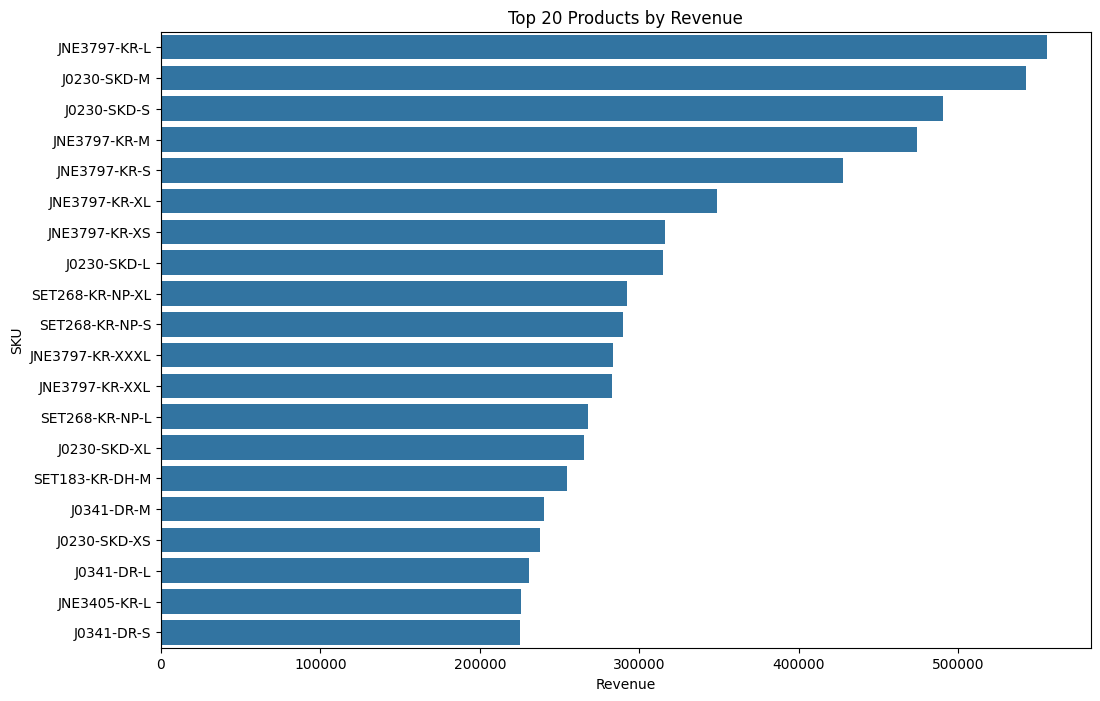

In [26]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_revenue.values, y=top_revenue.index)
plt.title("Top 20 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("SKU")
plt.show()

**4. Which are the 20 cities that made the most orders?**

In [27]:
top_cities = df["ship_city"].value_counts().head(20)
print(top_cities)

ship_city
BENGALURU        11217
HYDERABAD         8074
MUMBAI            6126
NEW DELHI         5795
CHENNAI           5421
PUNE              3857
KOLKATA           2381
GURUGRAM          1868
THANE             1701
LUCKNOW           1458
NOIDA             1419
GHAZIABAD         1328
NAVI MUMBAI       1263
AHMEDABAD         1236
JAIPUR             948
Hyderabad          919
Mumbai             868
COIMBATORE         768
PATNA              764
VISAKHAPATNAM      761
Name: count, dtype: int64


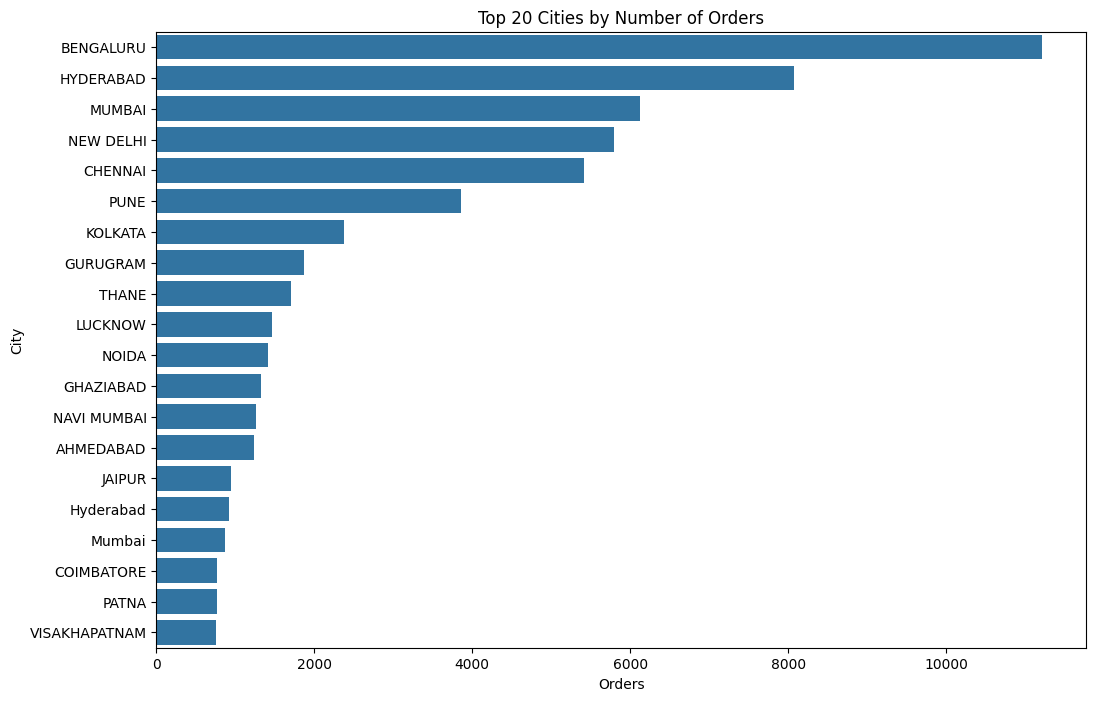

In [28]:
plt.figure(figsize=(12,8))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title("Top 20 Cities by Number of Orders")
plt.xlabel("Orders")
plt.ylabel("City")
plt.show()

**5. Which are the 20 cities that generated the most revenue?**

In [29]:
city_revenue = df.groupby("ship_city")["Amount"].sum().sort_values(ascending=False).head(20)
print(city_revenue)

ship_city
BENGALURU        7135213.82
HYDERABAD        5200624.00
MUMBAI           3840271.98
NEW DELHI        3805632.14
CHENNAI          3259569.08
PUNE             2444875.68
KOLKATA          1489208.37
GURUGRAM         1264414.24
THANE            1055126.79
LUCKNOW           988935.34
NOIDA             951138.99
GHAZIABAD         875635.46
AHMEDABAD         800377.20
NAVI MUMBAI       795127.31
JAIPUR            635461.22
Hyderabad         603105.95
Mumbai            541915.89
PATNA             527599.05
VISAKHAPATNAM     477709.62
FARIDABAD         474609.50
Name: Amount, dtype: float64


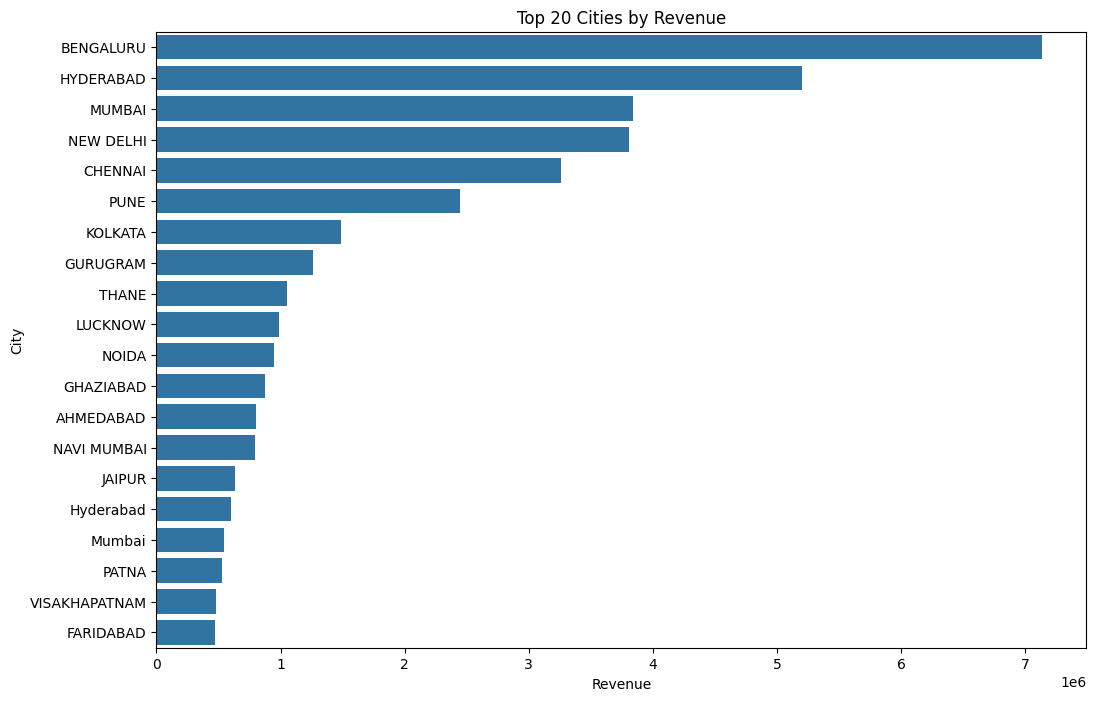

In [30]:
plt.figure(figsize=(12,8))
sns.barplot(x=city_revenue.values, y=city_revenue.index)
plt.title("Top 20 Cities by Revenue")
plt.xlabel("Revenue")
plt.ylabel("City")
plt.show()

**6. How many orders are fulfilled by Amazon and how many by the Merchant?**

In [31]:
fulfilment = df["Fulfilment"].value_counts()
print(fulfilment)

Fulfilment
Amazon      89678
Merchant    39264
Name: count, dtype: int64


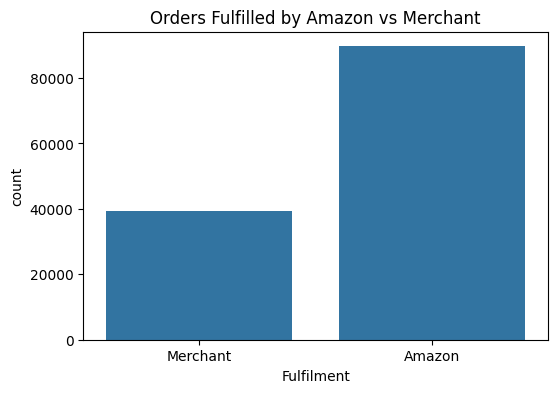

In [32]:
plt.figure(figsize=(6,4))
sns.countplot(x="Fulfilment", data=df)
plt.title("Orders Fulfilled by Amazon vs Merchant")
plt.show()

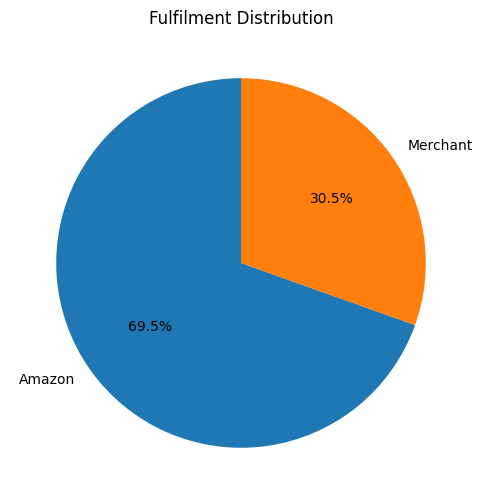

In [33]:
fulfilment = df["Fulfilment"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    fulfilment.values,
    labels=fulfilment.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Fulfilment Distribution")
plt.show()